In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
from math import ceil
import socket
import scipy.signal as signal

%matplotlib widget

## Notebook Setup

##### Append Code and Data Repository Paths

In [2]:
# Path to get to /home/rfsoc
home_dir = Path("./../..")
os.chdir(home_dir)

# Paths relative to /home/rfsoc
primecam_readout = Path('./primecam_readout')
ccatkidlib = Path('./ccatkidlib')
data_dir = Path('./../../mnt/md0')
 
# Append paths
sys.path.insert(0, os.path.abspath(ccatkidlib / 'rfsoc')) # Path contaning rfsoc_daq

##### Load Local Modules

In [30]:
%load_ext autoreload
%autoreload 2

from rfsoc_daq import R
import rfsoc_io
from rfsoc_timestream import Streamer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## Data Acquisiton

In [31]:
# Initialize Control Object
R = R()

INFO | The directory '/mnt/md0/TEMP_DATA/timestream/20241201/1733028632/B1D1' was successfully created!
INFO | The directory '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D1' was successfully created!
INFO | The directory '/mnt/md0/TEMP_DATA/targ/20241201/1733028632/B1D1' was successfully created!
INFO | The directory '/mnt/md0/TEMP_DATA/rfsoc/20241201/1733028632/B1D1' was successfully created!
INFO | The directory '/mnt/md0/TEMP_DATA/timestream/20241201/1733028632/B1D2' was successfully created!
INFO | The directory '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D2' was successfully created!
INFO | The directory '/mnt/md0/TEMP_DATA/targ/20241201/1733028632/B1D2' was successfully created!
INFO | The directory '/mnt/md0/TEMP_DATA/rfsoc/20241201/1733028632/B1D2' was successfully created!
INFO | The directory '/mnt/md0/TEMP_DATA/timestream/20241201/1733028632/B1D3' was successfully created!
INFO | The directory '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D3' was successfully created!
INF

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:20<00:00,  1.00s/it]


INFO | Initialized RFSoC agent. Communicating with drones: ['1.1', '1.2', '1.3', '1.4']!
INFO | Set NCLO to [850, 850, 500, 500] MHz for drones: ['1.1', '1.2', '1.3', '1.4']!
INFO | Successfully set drive attenuation to [10, 6, 10, 10] for drones ['1.1', '1.2', '1.3', '1.4']!
INFO | Successfully set sense attenuation to [2, 2, 2, 2] for drones ['1.1', '1.2', '1.3', '1.4']!


In [32]:
R.find_detectors(new_sweep = False, peak_prom_std = 10, peak_prom_dB = 0, width_min = 5, width_max = 100, peak_dis = 100)

Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.4: ip=192.168.2.99, to_run=True, running=True
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D1' with identifier 'T*'
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D2' with identifier 'T*'
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D3' with identifier 'T*'
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D4' with identifier 'T*'
Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.4: ip=192.168.2.99, to_run=True, running=True
INFO | Writing new VNA comb!
INFO | 

Writing custom target comb: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 117/117 [01:57<00:00,  1.00s/it]


INFO | Found 109 detectors for drone 1.1!
INFO | Found 35 detectors for drone 1.2!
INFO | Found 1 detectors for drone 1.3!
INFO | Found 528 detectors for drone 1.4!


[109, 35, 1, 528]

In [13]:
R.take_target_sweep()

Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=False, running=False
Status: Drone 1.4: ip=192.168.2.99, to_run=True, running=True
WARNING | '[]' is an empty array, not writing to custom comb file for drone 1.1!
WARNING | '[]' is an empty array, not writing to custom comb file for drone 1.1!
WARNING | '[]' is an empty array, not writing to custom comb file for drone 1.2!
WARNING | '[]' is an empty array, not writing to custom comb file for drone 1.2!
WARNING | '[]' is an empty array, not writing to custom comb file for drone 1.4!
WARNING | '[]' is an empty array, not writing to custom comb file for drone 1.4!
INFO | Sucessfully wrote custom comb for drone 1.1!
INFO | Sucessfully wrote custom comb for drone 1.2!
INFO | Sucessfully wrote custom comb for drone 1.4!
INFO | Taking target sweep!
INFO | Finished taking target sweep for drone 1.1!
INFO | Taking target sweep!
I

[PosixPath('/mnt/md0/TEMP_DATA/targ/20241201/1733025359/B1D1/TEST_targ_1733026306.npy'),
 PosixPath('/mnt/md0/TEMP_DATA/targ/20241201/1733025359/B1D2/TEST_targ_1733026306.npy'),
 PosixPath('/mnt/md0/TEMP_DATA/targ/20241201/1733025359/B1D4/TEST_targ_1733026306.npy')]

In [20]:
R.take_timestream(10)

Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=False, running=False
Status: Drone 1.4: ip=192.168.2.99, to_run=True, running=True
INFO | Taking 10 seconds of timestream data!
INFO | Finished taking timestream data for drone 1.1!
INFO | Finished taking timestream data for drone 1.2!
INFO | Finished taking timestream data for drone 1.4!


[[PosixPath('/mnt/md0/TEMP_DATA/timestream/20241130/1732949747/B1D1/TEST_tstream_1732950443_001.npy')],
 [PosixPath('/mnt/md0/TEMP_DATA/timestream/20241130/1732949747/B1D2/TEST_tstream_1732950443_001.npy')],
 [PosixPath('/mnt/md0/TEMP_DATA/timestream/20241130/1732949747/B1D4/TEST_tstream_1732950443_001.npy')]]

---

## Data Processing

In [33]:
# Data Directory Name
data_name = 'TEMP_DATA'
date = '20241201'
sess_id = '1733028632'

In [34]:
# Load init IO config
io_cfg_name = f'{sess_id}_init_config_io.yaml'
cfg_dir = data_dir / data_name / 'rfsoc' / date / sess_id

io_cfg = rfsoc_io.load_config(cfg_dir / io_cfg_name)
print(io_cfg)

{'sess_id': '1733028632', 'drone_list': ['1.1', '1.2', '1.3', '1.4'], 'parallel': True, 'restart': False, 'udp_ip': '192.168.3.40', 'udp_port': 4096, 'boards': {'b1': {'board_ip': '192.168.2.99', 'sampling_freq': '512e6/(2**20)', 'drone_cfg': '/home/rfsoc/ccatkidlib/rfsoc/drones_config_1.yaml'}, 'b2': {'board_ip': '192.168.2.98', 'sampling_freq': '512e6/(2**20)', 'drone_cfg': '/home/rfsoc/ccatkidlib/rfsoc/drones_config_2.yaml'}}, 'file_paths': {'analysis_dir': '/home/rfsoc/ccatkidlib/analysis/', 'data_dir': '/mnt/md0/TEMP_DATA', 'tmp_data_dir': '/home/rfsoc/primecam_readout/src/tmp', 'primecam_readout': '/home/rfsoc/primecam_readout/src/', 'master_drone_list': '/home/rfsoc/primecam_readout/master_drone_list.yaml', 'pcs_dir': '/home/rfsoc/ocs-site-configs/', 'RSA_key': '/home/rfsoc/.ssh/xilinx', 'drone_dir': '/home/xilinx/primecam_readout/drones'}, 'file_names': {'stream_fname': 'TEST_tstream_{self.timestamp}', 'targ_fname': 'TEST_targ_{self.timestamp}', 'vna_fname': 'TEST_vna_{self.tim

In [35]:
# Get parameters from io_cfg
drone_list = io_cfg['drone_list']
print(drone_list)

['1.1', '1.2', '1.3', '1.4']


### Sweeps

In [36]:
def plot_sweep(sweep_file, figax = None, label = "", n = 10):
    # Create axes object or use passed axes object
    if figax is None:
        fig, ax = plt.subplots(figsize = (8, 8))
    else:
        fig, ax = figax
    
    # Load VNA sweep data
    fs, s21z = np.load(sweep_file)
    fs = np.abs(fs) 
    s21m = np.abs(s21z)
    s21dB = 20*np.log10(s21m)
    
    ax.plot(fs[n:]/1e6, signal.medfilt(s21dB, kernel_size = n)[n:], label = label)
    #ax.set_xlabel("Frequency (MHz)")
    #ax.set_ylabel("|S21| (dB)")

    # Create legend if label was provided
    if label != "":
        ax.legend(loc = 1)
        
    return fs, s21z

##### VNA Sweeps

In [37]:
# Define VNA sweep data directory
vna_sweep_name = 'TEST_vna_'
vna_dir = data_dir / data_name / 'vna' / date / sess_id

for drone in drone_list:
    bid, drid = drone.split('.')
    dir_name = f'B{bid}D{drid}/'
    print(dir_name + ": " + str(os.listdir(vna_dir / dir_name)))

B1D1/: ['TEST_vna_1733028805.npy']
B1D2/: ['TEST_vna_1733028805.npy']
B1D3/: ['TEST_vna_1733028805.npy']
B1D4/: ['TEST_vna_1733028805.npy']


Text(0.5, 0.98, 'VNA Traces')

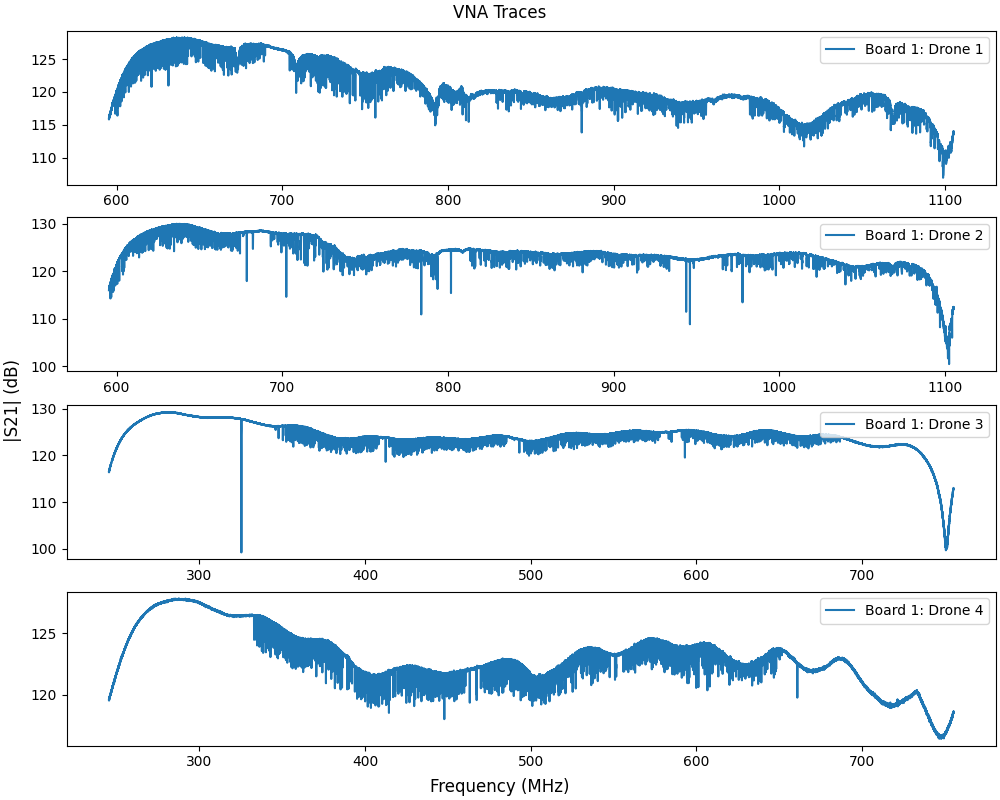

In [39]:
# Define timestamp of VNA sweeps
timestamp = '1733028805'

# Plot VNA sweeps
num_cols = 1 # Define desired number of columns in figure
num_rows = ceil(len(drone_list) / num_cols) # Calculate number of rows necessary to plot all VNA sweeps

# Create figure
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_vna)
except:
    print("No figures currently open")

fig_vna, axes = plt.subplots(num_rows, num_cols, figsize = (10, 8), constrained_layout = True)

# Iterate through each drone and plot corresponding VNA sweep
for drone, ax in zip(drone_list, np.ndarray.flatten(axes)):
    bid, drid = drone.split('.')
    fname = vna_dir / (f'B{bid}D{drid}/' + vna_sweep_name + timestamp + ".npy")
    plot_sweep(fname, figax = (fig_vna, ax), label = f'Board {bid}: Drone {drid}', n = 7)
fig_vna.supxlabel("Frequency (MHz)")
fig_vna.supylabel("|S21| (dB)")
fig_vna.suptitle("VNA Traces")

---

#### Target Sweep

In [14]:
# Define target sweep data directory
targ_sweep_name = 'TEST_targ_'
targ_dir = data_dir / data_name / 'targ' / date / sess_id

for drone in drone_list:
    bid, drid = drone.split('.')
    dir_name = f'B{bid}D{drid}/'
    print(dir_name + ": " + str(os.listdir(targ_dir / dir_name)))

B1D1/: ['TEST_targ_1733026306.npy']
B1D2/: ['TEST_targ_1733026306.npy']
B1D4/: ['TEST_targ_1733026306.npy']


No figures currently open


Text(0.5, 0.98, 'Target Traces')

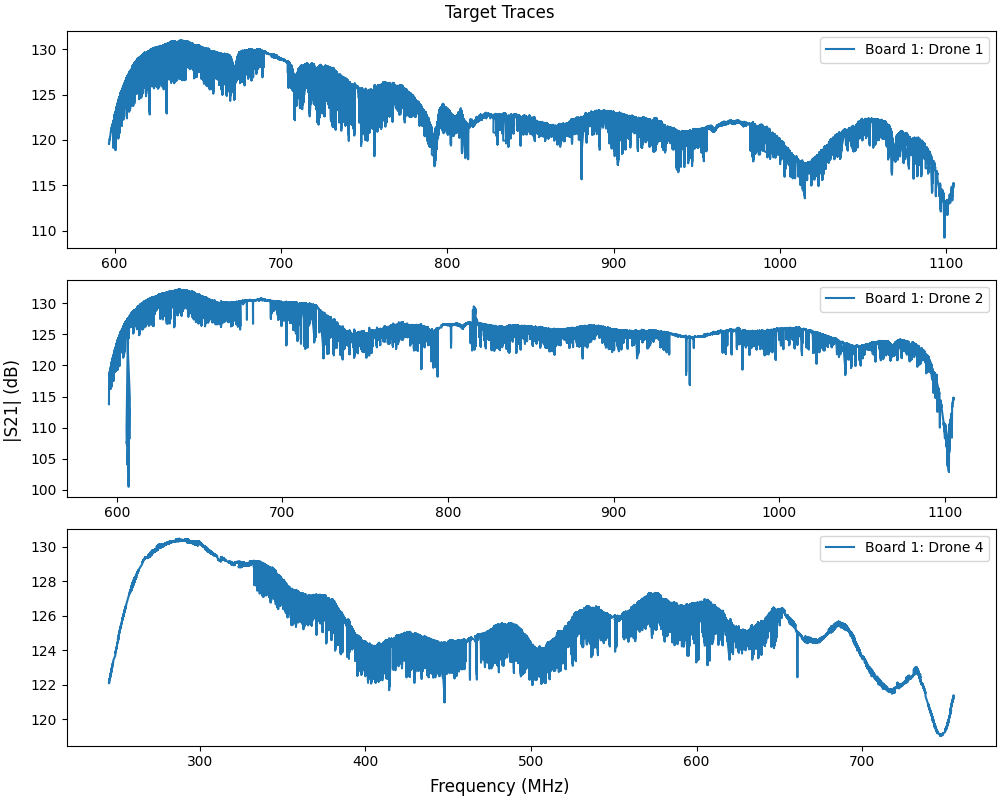

In [15]:
# Define timestamp of target sweeps
timestamp = '1733026306'

# Plot target sweeps
num_cols = 1 # Define desired number of columns in figure
num_rows = ceil(len(drone_list) / num_cols) # Calculate number of rows necessary to plot all target sweeps

# Create figure
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_targ)
except:
    print("No figures currently open")

fig_targ, axes = plt.subplots(num_rows, num_cols, figsize = (10, 8), constrained_layout = True)

# Iterate through each drone and plot corresponding VNA sweep
for drone, ax in zip(drone_list, np.ndarray.flatten(axes)):
    bid, drid = drone.split('.')
    fname = targ_dir / (f'B{bid}D{drid}/' + targ_sweep_name + timestamp + ".npy")
    plot_sweep(fname, figax = (fig_targ, ax), label = f'Board {bid}: Drone {drid}', n = 7)
fig_targ.supxlabel("Frequency (MHz)")
fig_targ.supylabel("|S21| (dB)")
fig_targ.suptitle("Target Traces")

---

### Timestreams

In [21]:
def plot_tstream(tstream_file, chans = None, figax = None, label = ""):
    # Create axes object or use passed axes object
    if figax is None:
        fig, ax = plt.subplots(figsize = (8, 8))
    else:
        fig, ax = figax

    try:
        chan_num = len(chans)
    except:
        chans = [chans]
        chan_num = len(chans)
    
    # Load timestream data
    data = np.load(tstream_file)
    ts = data[0]

    for chan in chans:
        s21z = data[chan]
        s21m = np.abs(s21z)
        ax.plot(ts, 20*np.log10(s21m), label = label + f', Channel: {chan}')
        #ax.set_xlabel("Frequency (MHz)")
        #ax.set_ylabel("|S21| (dB)")

        # Create legend if label was provided
        if label != "":
            ax.legend(loc = 1)

In [22]:
# Define timestream data directory
tstream_name = 'TEST_tstream_'
tstream_dir = data_dir / data_name / 'timestream' / date / sess_id

for drone in drone_list:
    bid, drid = drone.split('.')
    dir_name = f'B{bid}D{drid}/'
    print(dir_name + ": " + str(os.listdir(tstream_dir / dir_name)))

B1D1/: ['TEST_tstream_1732950443_001.npy']
B1D2/: ['TEST_tstream_1732950443_001.npy']
B1D4/: ['TEST_tstream_1732950443_001.npy']


No figures currently open


/home/rfsoc/env_rfsoc/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/rfsoc/env_rfsoc/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 0.98, 'Timestreams')

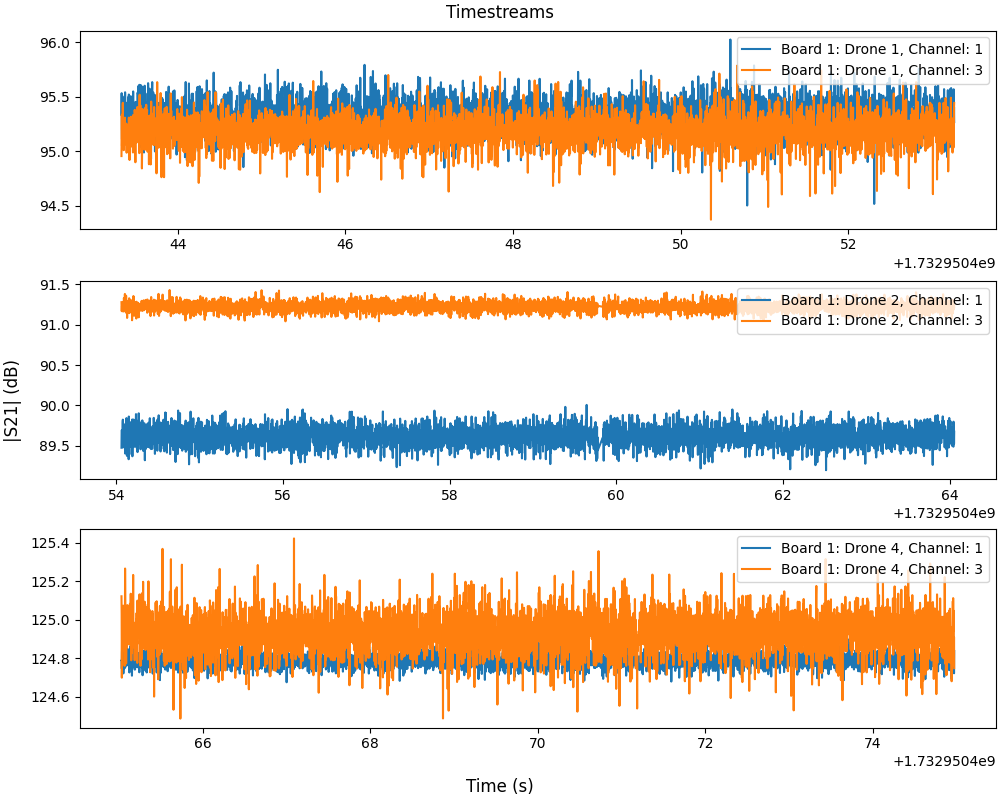

In [23]:
# Define timestamp of timestreams
timestamp = '1732950443_001'

# Plot timestreams
num_cols = 1 # Define desired number of columns in figure
num_rows = ceil(len(drone_list) / num_cols) # Calculate number of rows necessary to plot all timestreams

# Create figure
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_tstream)
except:
    print("No figures currently open")

fig_tstream, axes = plt.subplots(num_rows, num_cols, figsize = (10, 8), constrained_layout = True)

# Iterate through each drone and plot corresponding VNA sweep
channels = [[1,3],[1,3], [1,3]]
for drone, chans, ax in zip(drone_list, channels, np.ndarray.flatten(axes)):
    bid, drid = drone.split('.')
    fname = tstream_dir / (f'B{bid}D{drid}/' + tstream_name + timestamp + ".npy")
    plot_tstream(fname, chans = chans, figax = (fig_tstream, ax), label = f'Board {bid}: Drone {drid}')
fig_tstream.supxlabel("Time (s)")
fig_tstream.supylabel("|S21| (dB)")
fig_tstream.suptitle("Timestreams")

In [25]:
[1, 3, 4].tolist()

AttributeError: 'list' object has no attribute 'tolist'

In [26]:
np.array(np.array([1,2,3]))

array([1, 2, 3])